In [7]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from housing_env import HousingEnv

# ensure plots render inline
%matplotlib inline


### Define Simulation Parameters

In [8]:
# environment parameters
num_inspectors = 150
inspection_rate = 4
years = 1  # one year of data
max_active_reports = 600

# storage for history
history = []

# Check date range in the data
df_check = pd.read_csv("data/311_preproc.csv")
df_check['Created Date'] = pd.to_datetime(df_check['Created Date'])
min_date = df_check['Created Date'].min()
max_date = df_check['Created Date'].max()
print(f"\nData Date Range:")
print(f"  Earliest: {min_date.date()}")
print(f"  Latest: {max_date.date()}")
print(f"  Total days: {(max_date - min_date).days}")

# Determine training and test periods
# Example: Train on first 5 years, test on year 6
train_start = min_date.date()
train_end = train_start + datetime.timedelta(days=365*5)
test_start = train_end + datetime.timedelta(days=1)
test_end = test_start + datetime.timedelta(days=365)

print(f"\nProposed Split:")
print(f"  Training: {train_start} to {train_end} (5 years)")
print(f"  Testing: {test_start} to {test_end} (1 year)")


Data Date Range:
  Earliest: 2020-01-01
  Latest: 2026-02-22
  Total days: 2244

Proposed Split:
  Training: 2020-01-01 to 2024-12-30 (5 years)
  Testing: 2024-12-31 to 2025-12-31 (1 year)



## Train RL Agents

This section trains three agents: a random baseline, a TD-learning agent, and a Deep Q-Network.

In [9]:
# Install and Import Stable Baselines3

import subprocess
import sys
from gymnasium import spaces, Wrapper
from stable_baselines3 import DQN
import gymnasium as gym

# Wrapper to flatten Dict observation Space (keeps compatibility with SB3)
class FlattenDictObsWrapper(Wrapper):
    """Convert Dict observation to flattened Box observation for Stable Baselines3."""
    def __init__(self, env):
        super().__init__(env)
        reports_shape = env.observation_space["reports"].shape
        mask_shape = env.observation_space["mask"].shape
        inspectors_shape = env.observation_space["inspectors"].shape if isinstance(env.observation_space["inspectors"], spaces.Box) else (1,)
        timestep_shape = env.observation_space["timestep"].shape if isinstance(env.observation_space["timestep"], spaces.Box) else (1,)
        
        flat_size = (reports_shape[0] * reports_shape[1] + 
                     mask_shape[0] + 
                     (inspectors_shape[0] if isinstance(inspectors_shape, tuple) else 1) +
                     (timestep_shape[0] if isinstance(timestep_shape, tuple) else 1))
        
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(flat_size,),
            dtype=np.float32
        )
    
    def reset(self, **kwargs):
        # Allow seed/options to be passed through; fallback for older envs
        kwargs.pop('seed', None)
        kwargs.pop('options', None)
        obs, info = self.env.reset(**kwargs)
        return self._flatten_obs(obs), info
    
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._flatten_obs(obs), reward, terminated, truncated, info
    
    def _flatten_obs(self, obs):
        # Flatten each component properly
        reports_flat = obs["reports"].flatten().astype(np.float32)
        mask_flat = obs["mask"].astype(np.float32)
        inspectors_flat = np.atleast_1d(np.asarray(obs["inspectors"], dtype=np.float32)).flatten()
        timestep_flat = np.atleast_1d(np.asarray(obs["timestep"], dtype=np.float32)).flatten()
        
        return np.concatenate([reports_flat, mask_flat, inspectors_flat, timestep_flat])

# Simple Random Agent for baseline (works with Discrete hierarchical action space)
class RandomAgent:
    """Baseline agent that takes random actions."""
    def __init__(self, env):
        self.env = env
        self.action_space = env.action_space
    
    def select_action(self, obs):
        return int(self.action_space.sample())

print("Environment wrappers and agent classes ready.")


Environment wrappers and agent classes ready.


In [10]:
# Import stable-baselines3
from stable_baselines3 import DQN
from gymnasium.wrappers import FlattenObservation

print("\n" + "="*60)
print("HIERARCHICAL DQN AGENT")
print("="*60)

# Create environment for training (5 years starting from earliest date)
print("\nCreating training environment (5 years: 2020-2024)...")
env_dqn_train = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=4,  # Train for 4 years
    max_active_reports=max_active_reports,
    hierarchical=True,
    data_path="data/311_preproc.csv",
    start_date_str=str(min_date.date()),  # Start from earliest date in dataset
)

# Flatten the observation space for DQN
env_dqn_train = FlattenObservation(env_dqn_train)

print(f"  Action space: {env_dqn_train.action_space}")
print(f"  Observation space: {env_dqn_train.observation_space}")

# Create DQN model
print("\nCreating DQN model...")
dqn_model = DQN(
    "MlpPolicy",
    env_dqn_train,
    learning_rate=1e-4,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    tau=1.0,
    target_update_interval=1000,
    exploration_fraction=0.1,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=0,
)

# Train for five years of timesteps
timesteps_for_5_years = int(365 * 5 * inspection_rate)
print(f"\nTraining DQN for {timesteps_for_5_years} timesteps (5 years)...")
dqn_model.learn(total_timesteps=timesteps_for_5_years, log_interval=500)

print("\n✓ DQN Training complete!")



HIERARCHICAL DQN AGENT

Creating training environment (5 years: 2020-2024)...
  Action space: Discrete(90000)
  Observation space: Box(0.0, 1.0, (6751,), float32)

Creating DQN model...

Training DQN for 7300 timesteps (5 years)...


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.70GB > 1.14GB
  warnings.warn(



✓ DQN Training complete!


In [11]:
# Evaluate both agents on fresh 1-year environment (test year)
print("\n" + "="*60)
print(f"TESTING BOTH AGENTS ON FRESH 1-YEAR ENVIRONMENT ({str(test_start)})")
print("="*60)

# Create fresh environment for testing (1 year) - use year after training
timesteps_per_year = int(365 * inspection_rate)

env_test = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=1,  # Test year
    max_active_reports=max_active_reports,
    hierarchical=True,
    data_path="data/311_preproc.csv",
    start_date_str=str(test_start),  # Test on year after training
)

env_test_wrapped = FlattenObservation(env_test)

# Test DQN on the test environment
print(f"\nEvaluating trained DQN on test year ({str(test_start)})...")
obs, info = env_test_wrapped.reset()
dqn_rewards = []
dqn_violations = []
dqn_reports_closed = []
dqn_open_reports = 0

for t in range(timesteps_per_year):
    action, _states = dqn_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test_wrapped.step(action)
    
    dqn_rewards.append(reward)
    violations_this_step = sum(1 for det in info.get('inspection_details', []) if det.get('outcome') == 'VIOLATION')
    reports_closed_this_step = len(info.get('inspection_details', []))
    dqn_violations.append(violations_this_step)
    dqn_reports_closed.append(reports_closed_this_step)
    dqn_open_reports = info.get('open_reports', 0)
    
    if (t + 1) % 200 == 0:
        print(f"  Timestep {t+1}/{timesteps_per_year}")
    
    if terminated or truncated:
        break

dqn_total_reward = sum(dqn_rewards)
dqn_total_violations = sum(dqn_violations)
dqn_total_closed = sum(dqn_reports_closed)

print(f"\nDQN Results (test year {str(test_start)}):")
print(f"  Total Reward: {dqn_total_reward:.2f}")
print(f"  Total Violations Fixed: {dqn_total_violations}")
print(f"  Total Reports Closed: {dqn_total_closed}")
print(f"  Final Open Reports: {dqn_open_reports}")
print(f"  Avg Reward per Timestep: {np.mean(dqn_rewards):.4f}")

print(f"\nEvaluating random baseline on same test year ({str(test_start)})...")

env_test_baseline = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=1,  # Same test year
    max_active_reports=max_active_reports,
    hierarchical=True,
    data_path="data/311_preproc.csv",
    start_date_str=str(test_start),  # Same test period
)

agent_test = RandomAgent(env_test_baseline)
obs, info = env_test_baseline.reset()
baseline_rewards = []
baseline_violations = []
baseline_reports_closed = []
baseline_open_reports = 0

for t in range(timesteps_per_year):
    action = agent_test.select_action(obs)
    obs, reward, terminated, truncated, info = env_test_baseline.step(action)
    
    baseline_rewards.append(reward)
    violations_this_step = sum(1 for det in info.get('inspection_details', []) if det.get('outcome') == 'VIOLATION')
    reports_closed_this_step = len(info.get('inspection_details', []))
    baseline_violations.append(violations_this_step)
    baseline_reports_closed.append(reports_closed_this_step)
    baseline_open_reports = info.get('open_reports', 0)
    
    if (t + 1) % 200 == 0:
        print(f"  Timestep {t+1}/{timesteps_per_year}")
    
    if terminated or truncated:
        break

baseline_total_reward = sum(baseline_rewards)
baseline_total_violations = sum(baseline_violations)
baseline_total_closed = sum(baseline_reports_closed)

print(f"\nRandom Baseline Results (test year {str(test_start)}):")
print(f"  Total Reward: {baseline_total_reward:.2f}")
print(f"  Total Violations Fixed: {baseline_total_violations}")
print(f"  Total Reports Closed: {baseline_total_closed}")
print(f"  Final Open Reports: {baseline_open_reports}")
print(f"  Avg Reward per Timestep: {np.mean(baseline_rewards):.4f}")


TESTING BOTH AGENTS ON FRESH 1-YEAR ENVIRONMENT (2024-12-31)

Evaluating trained DQN on test year (2024-12-31)...
  Timestep 200/1460

DQN Results (test year 2024-12-31):
  Total Reward: 2409.00
  Total Violations Fixed: 94
  Total Reports Closed: 365
  Final Open Reports: 599
  Avg Reward per Timestep: 6.6000

Evaluating random baseline on same test year (2024-12-31)...
  Timestep 200/1460

Random Baseline Results (test year 2024-12-31):
  Total Reward: 2109.00
  Total Violations Fixed: 78
  Total Reports Closed: 365
  Final Open Reports: 599
  Avg Reward per Timestep: 5.7781



COMPARISON: RANDOM BASELINE vs. HIERARCHICAL DQN (1 Year)


                 Metric Random Baseline Hierarchical DQN
           Total Reward         2109.00          2409.00
 Total Violations Fixed              78               94
   Total Reports Closed             365              365
     Final Open Reports             599              599
Avg Reward per Timestep          5.7781           6.6000

DQN Improvements over Random Baseline:
  Total Reward: +14.2%
  Total Violations Fixed: +20.5%
  Total Reports Closed: +0.0%


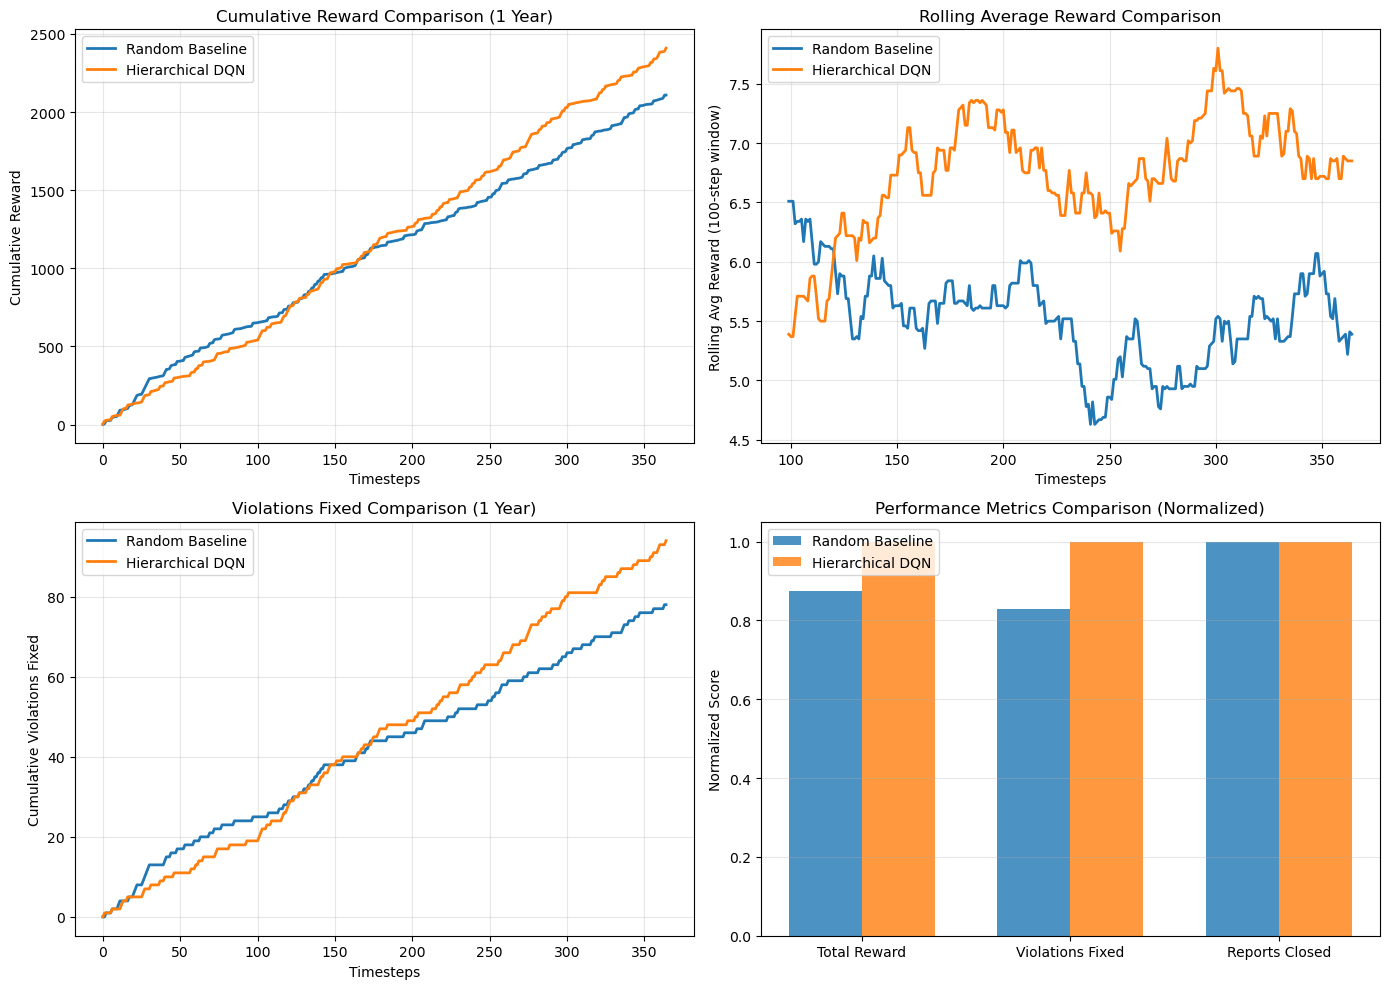

In [12]:
# Comparison Summary
print("\n" + "="*60)
print("COMPARISON: RANDOM BASELINE vs. HIERARCHICAL DQN (1 Year)")
print("="*60)

comparison_data = {
    'Metric': [
        'Total Reward',
        'Total Violations Fixed',
        'Total Reports Closed',
        'Final Open Reports',
        'Avg Reward per Timestep'
    ],
    'Random Baseline': [
        f"{baseline_total_reward:.2f}",
        f"{baseline_total_violations}",
        f"{baseline_total_closed}",
        f"{baseline_open_reports}",
        f"{np.mean(baseline_rewards):.4f}"
    ],
    'Hierarchical DQN': [
        f"{dqn_total_reward:.2f}",
        f"{dqn_total_violations}",
        f"{dqn_total_closed}",
        f"{dqn_open_reports}",
        f"{np.mean(dqn_rewards):.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Calculate improvements
reward_improvement = ((dqn_total_reward - baseline_total_reward) / abs(baseline_total_reward)) * 100
violations_improvement = ((dqn_total_violations - baseline_total_violations) / max(baseline_total_violations, 1)) * 100
closed_improvement = ((dqn_total_closed - baseline_total_closed) / max(baseline_total_closed, 1)) * 100

print(f"\nDQN Improvements over Random Baseline:")
print(f"  Total Reward: {reward_improvement:+.1f}%")
print(f"  Total Violations Fixed: {violations_improvement:+.1f}%")
print(f"  Total Reports Closed: {closed_improvement:+.1f}%")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cumulative Rewards
ax = axes[0, 0]
ax.plot(np.cumsum(baseline_rewards), label='Random Baseline', linewidth=2)
ax.plot(np.cumsum(dqn_rewards), label='Hierarchical DQN', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward Comparison (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Rolling Average Reward (100-timestep window)
ax = axes[0, 1]
window = 100
baseline_rolling = pd.Series(baseline_rewards).rolling(window=window).mean()
dqn_rolling = pd.Series(dqn_rewards).rolling(window=window).mean()
ax.plot(baseline_rolling, label='Random Baseline', linewidth=2)
ax.plot(dqn_rolling, label='Hierarchical DQN', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel(f'Rolling Avg Reward ({window}-step window)')
ax.set_title('Rolling Average Reward Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative Violations Fixed
ax = axes[1, 0]
ax.plot(np.cumsum(baseline_violations), label='Random Baseline', linewidth=2)
ax.plot(np.cumsum(dqn_violations), label='Hierarchical DQN', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Cumulative Violations Fixed')
ax.set_title('Violations Fixed Comparison (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Summary Bar Chart
ax = axes[1, 1]
metrics = ['Total Reward', 'Violations Fixed', 'Reports Closed']
baseline_vals = [baseline_total_reward, baseline_total_violations, baseline_total_closed]
dqn_vals = [dqn_total_reward, dqn_total_violations, dqn_total_closed]

x = np.arange(len(metrics))
width = 0.35

# Normalize for visualization if ranges differ significantly
baseline_norm = [v / max(baseline_vals[i], dqn_vals[i]) if max(baseline_vals[i], dqn_vals[i]) > 0 else 0 for i, v in enumerate(baseline_vals)]
dqn_norm = [v / max(baseline_vals[i], dqn_vals[i]) if max(baseline_vals[i], dqn_vals[i]) > 0 else 0 for i, v in enumerate(dqn_vals)]

ax.bar(x - width/2, baseline_norm, width, label='Random Baseline', alpha=0.8)
ax.bar(x + width/2, dqn_norm, width, label='Hierarchical DQN', alpha=0.8)
ax.set_ylabel('Normalized Score')
ax.set_title('Performance Metrics Comparison (Normalized)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()